# RNN and LSTM for Fully Observable choatic Systems

This notebook demonstrates the use of Recurrent Neural Networks (RNNs) and LSTM for modeling and forecasting fully observable chaotic systems. We will work with well-known chaotic systems such as the Lorenz system, Rabinovich-Fabrikant system, and Rossler system. The workflow includes data simulation, preprocessing, model training, and evaluation."

# 1: Import Dependencies

We begin by importing all required modules:

- **Standard libraries** for deep learning (`torch`, `nn`), data handling (`pandas`), and visualization (`matplotlib`)
- **Lorenz system simulator** from `chaotic_data.systems` to generate synthetic chaotic time series
- **Data utilities** like preprocessing and plotting helpers
- **Model classes**: `RNN_Model` and `LSTM_Model` from the `src.models.classic` module
- **Custom Trainer**: `RNNTrainer` which handles training, validation, and saving checkpoints


In [1]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from chaotic_data import systems  # Lorenz/chaotic system data generator
from data_utils import preprocess, plottings  # normalization, dataloaders, visualization

# from hcnn.core.models.classic_models import RNNModel as RNN_Model, LSTMModel as LSTM_Model
# # [MIGRATION NEEDED - no hcnn classic single-trainer yet] from src.single_trainers.classic_training import RNNTrainer  # wherever your trainer is saved


In [2]:
from hcnn.core.ensembles.classic_ensembles import RNNEnsemble, LSTMEnsemble


> `src`, `chaotic_data`, and `data_utils` are modules available in the repo 

## 2: Simulate the Lorenz System

We generate a synthetic multivariate time series using the Lorenz chaotic system.

- The Lorenz system is a classic example of a deterministic chaotic system.
- We specify:
  - `start` and `stop`: the time interval for simulation
  - `ics`: initial conditions (x=1.0, y=0.0, z=1.25)
  - `time_grid`: simulation step size

The result is a NumPy array of shape `(T, 3)` where each column represents a variable (x, y, z) over time.


In [3]:
lorenz_data, _ = systems.LorenzSolver(start=0.0, stop=20.0, ics=(1.0, 0.0, 1.25), time_grid=0.01)

print(lorenz_data.shape)


torch.Size([2000, 3])


We plot the first state variable of the Lorenz system to observe its chaotic behavior over time."



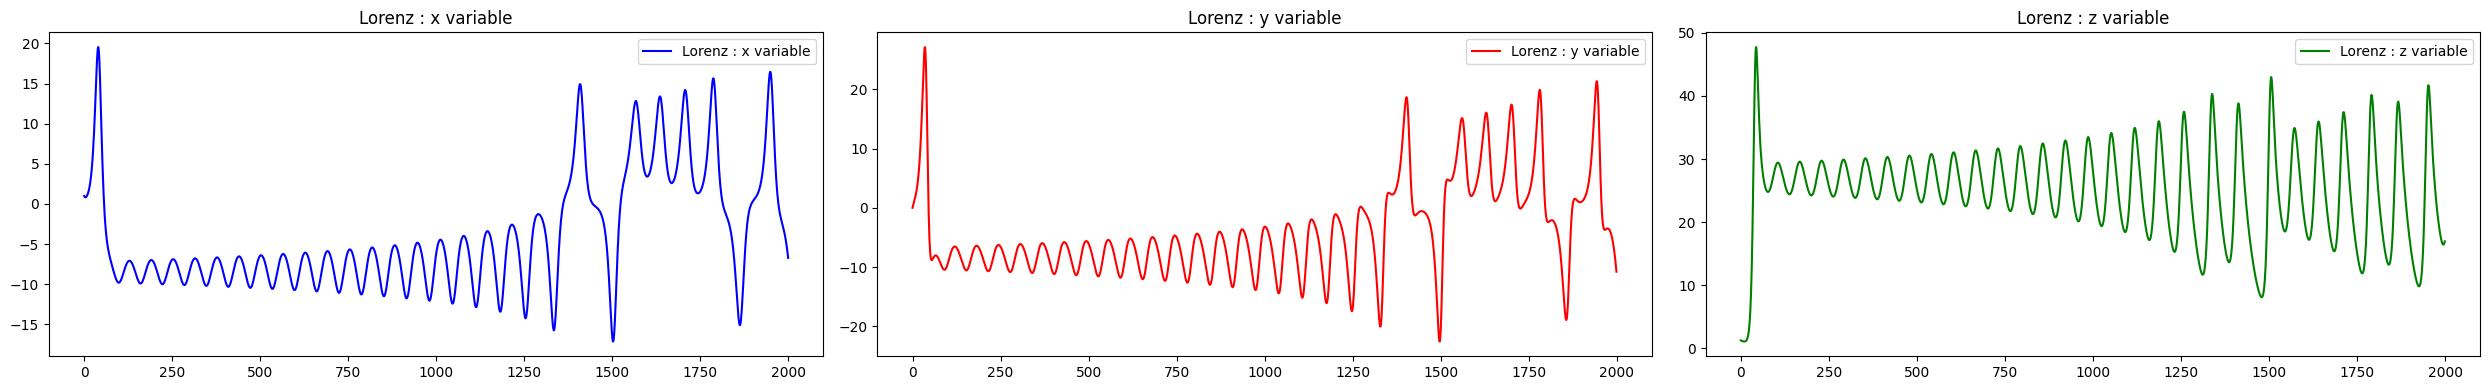

In [4]:
plotter_lorenz  =plottings.ChaoticSystemPlotter(data=lorenz_data, system_name='Lorenz')
plotter_lorenz.plot_all_trajectories(render='horizontal')


## 3: Normalize the Lorenz Data

Before training, we normalize the Lorenz system outputs to improve convergence and stability.

- We use a custom `Normalization_Strategy` provided in `data_utils.preprocess`.
- `Scale_ToNormalize` performs **min-max scaling** or a domain-specific scaling with a custom `scaling_factor`.
- The function returns:
  - `scaled_lorenz`: normalized version of the data
  - `avg_lorenz`: average vector (useful for rescaling if needed)

We also truncate the dataset to the first 200 steps for a quicker training demo.


In [5]:
norma = preprocess.Normalization_Strategy()
scaled_lorenz, avg_lorenz = norma.Scale_ToNormalize(data=lorenz_data, scaling_factor=0.02)
scaled_lorenz = scaled_lorenz[:200]


print(scaled_lorenz.shape , avg_lorenz.shape)

torch.Size([200, 3]) torch.Size([3])


## 4: Split into Training and Testing Sets

To train and evaluate the model, we split the normalized data:

- **Training Set**: the first 150 timesteps
- **Testing Set**: the remaining 50 timesteps (used later for inference or visualization)

This is a simple chronological split suitable for time series forecasting tasks.


In [6]:
train_size = 150
train_lorenz = scaled_lorenz[:train_size]
test_lorenz = scaled_lorenz[train_size:]

print(train_lorenz.shape, test_lorenz.shape)


torch.Size([150, 3]) torch.Size([50, 3])


##  5: Create Sliding Windows and a DataLoader

To train sequence models like RNNs or LSTMs, we convert the time series into **overlapping input-output windows**.

- `InpTarg_TSDataset.create_train_loader(...)`
  - Automatically wraps sliding windows into a PyTorch `DataLoader`
  - `window_size=10` creates input sequences of 10 timesteps
  - `batch_size=5` defines how many samples per batch

- `SlidingWindowDataset(...)` and `sliding_windows_shift_to(...)`
  - Also generate sliding windows directly as a NumPy/torch array
  - Useful for inspection, plotting, or building custom datasets


In [7]:
my_rnn_data_loader = preprocess.InpTarg_TSDataset.create_train_loader(
    data=train_lorenz, window_size=10, batch_size=5, shuffle=False
)

for inp_, out_ in my_rnn_data_loader:
    print(inp_.shape, out_.shape)

    break

torch.Size([5, 10, 3]) torch.Size([5, 10, 3])


In [8]:
data_sliding = preprocess.SlidingWindowDataset(data=train_lorenz, window_size=10)
sliced_data = data_sliding.sliding_windows_shift_to(train_lorenz, 10)

print(sliced_data.shape)


torch.Size([141, 10, 3])


##  6: Create Calibration and Forecast Windows

For validation and forecasting tasks, we need a **calibration window** (context) and the **ground-truth future** (target):

- `context_size`: how many past timesteps to use as model input
- `fcast_size`: how many future timesteps to forecast
- `location`:
  - `'random_'`: sample a random forecast segment
  - `'last_'`: use the last available portion of the time series

These sequences are used by the trainer during `train_validate()` or for manual forecasting evaluation.


In [9]:
context_data_r, toforecast_data_r = data_sliding.contextwindow_testdata_generator(
    context_size=5, fcast_size=30, location='random_'
)

print(context_data_r.shape, toforecast_data_r.shape)

torch.Size([5, 3]) torch.Size([30, 3])


In [10]:
context_data_l, toforecast_data_l = data_sliding.contextwindow_testdata_generator(
    context_size=1, fcast_size=50, location='last_'
)
print(context_data_l.shape, toforecast_data_l.shape)

torch.Size([1, 3]) torch.Size([50, 3])


##  7: Initialize the LSTM Forecasting Model

We now instantiate a custom `LSTM_Model` for multivariate time series forecasting.

- `input_size=3`: the number of features (x, y, z of the Lorenz system)
- `hidden_size=5`: number of hidden units in the LSTM layer
- `output_size=3`: the model predicts all 3 variables
- `s0_nature='random_'`: initial hidden state is randomized
- `train_s0=True`: initial state is treated as a learnable parameter
- `init_range=(-0.75, 0.75)`: range for initializing model weights
- `num_layers=1`: a single LSTM layer

This model will be passed to the trainer in the next step.


In [11]:
my_lstm_ensemble = LSTMEnsemble( n_ensemble=5, input_size=3, hidden_size=5, output_size=3,
                                
                                s0_nature='random_',train_s0=True, init_range=(-0.75, 0.75),
                                
                                optimizer='adam', learning_rate=1e-3)

In [12]:
my_lstm_ensemble.models

[{'member_1': LSTM_Model(
    (state_transition_layer): LSTM(3, 5, batch_first=True)
    (output_extraction_layer): Linear(in_features=5, out_features=3, bias=True)
  ),
  'optimizer_1': Adam (
  Parameter Group 0
      amsgrad: False
      betas: (0.9, 0.999)
      capturable: False
      differentiable: False
      eps: 1e-08
      foreach: None
      fused: None
      lr: 0.001
      maximize: False
      weight_decay: 0
  )},
 {'member_2': LSTM_Model(
    (state_transition_layer): LSTM(3, 5, batch_first=True)
    (output_extraction_layer): Linear(in_features=5, out_features=3, bias=True)
  ),
  'optimizer_2': Adam (
  Parameter Group 0
      amsgrad: False
      betas: (0.9, 0.999)
      capturable: False
      differentiable: False
      eps: 1e-08
      foreach: None
      fused: None
      lr: 0.001
      maximize: False
      weight_decay: 0
  )},
 {'member_3': LSTM_Model(
    (state_transition_layer): LSTM(3, 5, batch_first=True)
    (output_extraction_layer): Linear(in_featur

## 8: Configure the RNN Trainer

We now set up the `RNNTrainer` to manage model training, loss computation, backpropagation, and checkpointing.

- `model`: the `LSTM_Model` defined earlier
- `loss_fn`: `"logcosh"` is more robust than MSE to outliers (you can also use `"mse"`)
- `backprop_mode`: 
  - `"per_batch"`: update weights after each batch
  - `"per_epoch"`: accumulate loss and update once per epoch
- `learning_rate`: controls how fast the model learns
- `optimizer_type`: choose `"adam"` for adaptive learning or `"sgd"` for vanilla stochastic gradient descent

This trainer class also handles saving the best model checkpoints and tracking loss metrics automatically.


In [13]:
# [MIGRATION NEEDED - no hcnn classic ensemble-trainer yet] from src.ensemble_trainers.classic_training import EnsembleLSTMTrainer

In [14]:
my_lstm_trainer = EnsembleLSTMTrainer(ensembles=my_lstm_ensemble.models, loss_fn='mse',
                                      best_on='individual' )

The `RNNTrainer` class offers two complementary training strategies: `train_only` and `train_and_validate`. 

- The `train_only` method focuses purely on minimizing training loss. It iterates over the training sequence(s) for a fixed number of epochs, tracks the average loss per epoch, and saves the model checkpoint corresponding to the lowest training loss encountered. This mode is particularly useful for quick model prototyping or when a separate validation set is not available. 

- In contrast, the `train_and_validate` method integrates both training and evaluation within each epoch. After each training pass, the model uses a defined calibration window to generate forecasts, which are then compared against a known future sequence (validation target). The model is checkpointed based on its validation performance, ensuring generalization is prioritized over memorization. 

## 9.1: Train the Model (`train_only` mode)

We now train the model using the `train_only()` method:

- The model will learn exclusively from training data — no validation set is involved.
- It will run for **5 epochs**.
- At the end of each epoch:
  - Training loss is computed and logged.
  - The model is saved **only if it improves** the average training loss.
- Output:
  - A directory under `./checkpoints_<model_name>_<timestamp>/` containing:
    - `best_train_avg_loss.pth`: the best model weights
    - `epoch_losses.json`: training loss per epoch in JSON format


In [ ]:
my_lstm_trainer.train_only( data_loader= my_rnn_data_loader, num_epochs=5, backprop_mode='per_batch')

##  9.2: Train with Validation (`train_validate` mode)

We now switch to using the `RNN_Model` and perform **training + validation** using the `train_validate()` method:

- The model trains on sliding-window training batches from `my_rnn_data_loader`.
- After each epoch, it forecasts using:
  - `calibration_window`: a short historical window (`context_data_r`)
  - `val_data`: the ground-truth future to be predicted (`toforecast_data_r`)
- The trainer compares the forecast to the ground truth and computes validation loss.
- It saves the model if the validation performance improves.

📦 Output Artifacts:
- `best_val_avg_loss.pth`: model with the lowest validation loss
- `epoch_losses.json`: training and validation losses per epoch
- `forecast_results_epoch_*.csv`: predicted vs actual sequences for each epoch


In [16]:
from hcnn.core.ensembles.classic_ensembles import RNNEnsemble

In [22]:
my_rnn_ensemble = RNNEnsemble( n_ensemble=5, input_size=3, hidden_size=5, output_size=3,
                                
                                s0_nature='zeros_',train_s0=False, init_range=(-0.75, 0.75),
                                
                                optimizer='adam', learning_rate=1e-3)

In [23]:
# [MIGRATION NEEDED - no hcnn classic ensemble-trainer yet] from src.ensemble_trainers.classic_training import EnsembleRNNTrainer

In [24]:
my_rnn_trainer = EnsembleRNNTrainer(ensembles=my_rnn_ensemble.models, loss_fn='mse',
                                      best_on='median' )

In [ ]:
my_rnn_trainer.train_validate(  data_loader=my_rnn_data_loader,   
                              
                              calibration_window=context_data_r, 
                               
                                val_data=toforecast_data_r,  num_epochs=5 )

In [ ]:
rnn_trainer = RNNTrainer( model=rnn_model,   loss_fn="logcosh", backprop_mode="per_epoch", learning_rate=1e-4,   optimizer_type="adam")




In [ ]:
rnn_trainer.train_validate(   data_loader=my_rnn_data_loader,   calibration_window=context_data_r,  val_data=toforecast_data_r,  num_epochs=5 )